# Hidden Activity Experiment Analysis

Analysis of training with hidden neurons. Comparing configurations:
- **Clamped E-step**: Visible neurons clamped to teacher spikes, visible-only loss
- **Fully recurrent**: Direct surrogate gradient backprop through full recurrent network
- **Visible-driven**: Teacher visible spikes as FF input, hidden recurrence kept
- **Ignore hidden**: Feedforward model on visible neurons only

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import zarr
import torch
from connectome_snns.utils.reproducibility import load_experiment_config
from connectome_snns.training_utils.losses import VanRossumLoss
from connectome_snns.visualization import use_project_style, plot_spike_trains
from connectome_snns.visualization.scaling_factors import SF_PATHWAYS, plot_sf_trajectories
from connectome_snns.analysis import interleave_spike_trains

use_project_style()

In [ ]:
# Paths to stability check experiments
base_dir = load_experiment_config("em-algorithm.toml")["output_dir"].parent
teacher_dir = Path("/tachyon/groups/scratch/gzenke/bedfrory/dp-simulations/teacher-network")

experiments = {
    "em-algorithm": base_dir / "em-algorithm",
    "fully-recurrent": base_dir / "fully-recurrent",
    "ignore-hidden": base_dir / "ignore-hidden",
    "visible-driven": base_dir / "visible-driven",
}

# Check which experiments exist
for name, path in experiments.items():
    exists = path.exists()
    has_data = (path / "training_metrics.csv").exists() if exists else False
    print(f"{name}: {'OK' if has_data else 'MISSING'}")

In [3]:
# Load teacher spikes and metadata
teacher_spikes_zarr = zarr.open_group(
    teacher_dir / "results" / "spike_data.zarr", mode="r"
)
teacher_spikes = np.array(teacher_spikes_zarr["output_spikes"][:1, :, :])
dt = float(teacher_spikes_zarr.attrs.get("dt", 1.0))

# Load hidden neuron indices
first_exp = next(p for p in experiments.values() if p.exists())
hidden_info = np.load(first_exp / "targets" / "hidden_neurons.npz")
hidden_indices = hidden_info["hidden_indices"]
visible_indices = hidden_info["visible_indices"]

print(f"Teacher spikes: {teacher_spikes.shape}, dt={dt}ms")
print(f"Hidden: {len(hidden_indices)}, Visible: {len(visible_indices)}")

Teacher spikes: (1, 10000, 5000), dt=1.0ms
Hidden: 2500, Visible: 2500


## Stability Check: First E-Step Results

With no weight perturbation, the E-step should recover the teacher's hidden spikes exactly.

In [4]:
# Load inferred spikes from first E-step
inferred_spikes = {}
for name, path in experiments.items():
    estep_path = path / "em_iter_001" / "inferred_spikes.zarr"
    if estep_path.exists():
        zarr_root = zarr.open_group(estep_path, mode="r")
        inferred_spikes[name] = np.array(zarr_root["output_spikes"][:1, :, :])

print(f"Loaded {len(inferred_spikes)} experiments")

Loaded 5 experiments


In [ ]:
# Compute Van Rossum loss for each experiment
chunk_size = 200
van_rossum_loss = VanRossumLoss(
    tau_rise=10.0, tau_decay=100.0, dt=dt, window_size=chunk_size, device="cpu"
)

teacher_hidden_spikes = teacher_spikes[:, :, hidden_indices]

results = []
for name, spikes in inferred_spikes.items():
    min_time = min(spikes.shape[1], teacher_hidden_spikes.shape[1])
    n_chunks = min_time // chunk_size

    # Compute loss
    van_rossum_loss.reset_state()
    total_loss = 0.0
    for i in range(n_chunks):
        start, end = i * chunk_size, (i + 1) * chunk_size
        loss = van_rossum_loss(
            torch.from_numpy(spikes[:, start:end, :]).float(),
            torch.from_numpy(teacher_hidden_spikes[:, start:end, :]).float(),
        )
        total_loss += loss.item()
    avg_loss = total_loss / n_chunks

    # Compute firing rates
    duration_s = min_time * dt / 1000.0
    inferred_rates = spikes[0, :min_time, :].sum(axis=0) / duration_s
    teacher_rates = teacher_hidden_spikes[0, :min_time, :].sum(axis=0) / duration_s

    # Check exact match
    exact_match = np.array_equal(
        spikes[0, :min_time, :], teacher_hidden_spikes[0, :min_time, :]
    )

    results.append(
        {
            "Experiment": name,
            "Van Rossum Loss": f"{avg_loss:.4f}",
            "Inferred FR (Hz)": f"{inferred_rates.mean():.1f} +/- {inferred_rates.std():.1f}",
            "Teacher FR (Hz)": f"{teacher_rates.mean():.1f} +/- {teacher_rates.std():.1f}",
            "Exact Match": exact_match,
        }
    )

results_df = pd.DataFrame(results)
print("\nStability Check: First E-Step Results (Hidden Neurons)")
print("=" * 80)
print(results_df.to_string(index=False))

In [ ]:
# Plot spike trains: inferred vs teacher for each experiment
n_neurons_plot = 10
time_ms = 10000  # 10 seconds
time_steps = int(time_ms / dt)

for name, spikes in inferred_spikes.items():
    actual_time = min(time_steps, spikes.shape[1], teacher_spikes.shape[1])

    teacher_hidden = np.take(
        teacher_spikes[0, :actual_time, :], hidden_indices[:n_neurons_plot], axis=1
    )
    inferred_hidden = spikes[0, :actual_time, :n_neurons_plot]

    interleaved, ct_idx = interleave_spike_trains(teacher_hidden, inferred_hidden)

    fig = plot_spike_trains(
        spikes=interleaved,
        dt=dt,
        cell_type_indices=ct_idx,
        cell_type_names=["Teacher", "Inferred"],
        n_neurons_plot=2 * n_neurons_plot,
        n_compared=2,
        fraction=1.0,
        random_seed=None,
        title=f"First E-Step: {name}",
        ylabel="Neuron",
        figsize=(16, 8),
    )
    plt.tight_layout()
    plt.show()

## Stability Analysis: Training Dynamics Across EM Iterations

With scaling factors initialized at their target (1.0) and no weight perturbation, the EM algorithm should remain stable. We track scaling factors, loss, and firing rates across all EM iterations for each configuration.

In [7]:
# Load training metrics for all experiments
training_metrics = {}
for name, path in experiments.items():
    csv_path = path / "training_metrics.csv"
    if csv_path.exists():
        training_metrics[name] = pd.read_csv(csv_path)

print(f"Loaded training metrics for {len(training_metrics)} experiments")
for name, df in training_metrics.items():
    print(
        f"  {name}: {len(df)} rows, epochs {df['epoch'].iloc[0]}-{df['epoch'].iloc[-1]}"
    )

Loaded training metrics for 6 experiments
  free-e-visible-loss: 50 rows, epochs 5-250
  free-e-full-loss: 50 rows, epochs 5-250
  clamped-e-visible-loss: 50 rows, epochs 5-250
  clamped-e-full-loss: 50 rows, epochs 5-250
  clamped-ff-e-visible-loss: 50 rows, epochs 5-250
  end-to-end: 50 rows, epochs 5-250


In [ ]:
# Plot: Scaling factor trajectories for each experiment
colors = {
    "em-algorithm": "C0",
    "fully-recurrent": "C4",
    "ignore-hidden": "C8",
    "visible-driven": "C9",
}
labels = {
    "em-algorithm": "EM Algorithm",
    "fully-recurrent": "Fully Recurrent",
    "ignore-hidden": "Ignore Hidden",
    "visible-driven": "Visible-Driven",
}

fig = plot_sf_trajectories(
    training_metrics,
    colors=colors,
    label_fn=lambda n: labels[n],
    ylim=(0.9, 1.1),
    suptitle="Scaling Factor Stability Across EM Iterations",
    figsize=(12, 10),
)
plt.show()

In [ ]:
# Plot: Loss trajectories
fig, ax = plt.subplots(figsize=(10, 4))

for name, df in training_metrics.items():
    loss_col = "total_loss" if "total_loss" in df.columns else "van_rossum_loss"
    ax.plot(
        df["epoch"],
        df[loss_col],
        color=colors[name],
        linewidth=1.5,
        label=labels[name],
    )

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Loss Across Training", fontsize=14, fontweight="bold")
ax.set_ylim(0, None)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

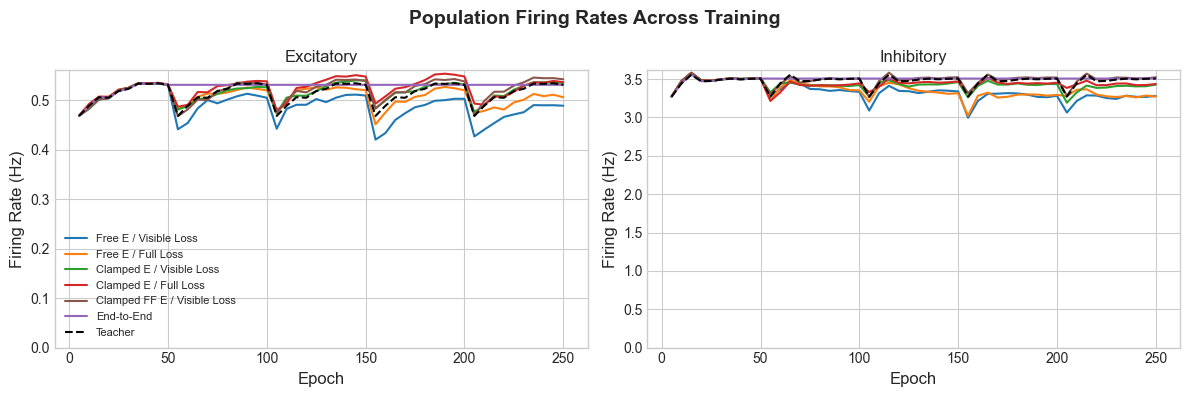

In [10]:
# Plot: Population firing rate trajectories
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


def _fr_col(df, role, cell_type, stat="mean"):
    """Get firing rate column, trying visibility-prefixed first."""
    prefixed = f"firing_rate/{role}_visible_{cell_type}_{stat}"
    simple = f"firing_rate/{role}_{cell_type}_{stat}"
    return prefixed if prefixed in df.columns else simple


fr_types = [("excitatory", "Excitatory"), ("inhibitory", "Inhibitory")]

for ax, (cell_type, title) in zip(axes, fr_types):
    for name, df in training_metrics.items():
        student_col = _fr_col(df, "student", cell_type)
        if student_col in df.columns:
            ax.plot(
                df["epoch"],
                df[student_col],
                color=colors[name],
                linewidth=1.5,
                label=labels[name],
            )

    # Teacher reference as trajectory (varies per chunk)
    first_df = next(iter(training_metrics.values()))
    teacher_col = _fr_col(first_df, "teacher", cell_type)
    if teacher_col in first_df.columns:
        ax.plot(
            first_df["epoch"],
            first_df[teacher_col],
            color="black",
            linestyle="--",
            linewidth=1.5,
            label="Teacher",
        )

    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Firing Rate (Hz)", fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, None)
    if title == "Excitatory":
        ax.legend(loc="best", fontsize=8)

plt.suptitle("Population Firing Rates Across Training", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Summary table: final values for each experiment
print("Stability Check Summary (Final Epoch)")
print("=" * 95)

rows = []
for name, df in training_metrics.items():
    final = df.iloc[-1]
    sf_values = [final[f"scaling_factors/{k}_value"] for k, _ in SF_PATHWAYS]
    sf_mean_dev = np.mean(np.abs(np.array(sf_values) - 1.0))

    exc_col = _fr_col(df, "student", "excitatory")
    inh_col = _fr_col(df, "student", "inhibitory")
    loss_col = "total_loss" if "total_loss" in df.columns else "van_rossum_loss"

    rows.append(
        {
            "Experiment": labels[name],
            "Final Loss": f"{final[loss_col]:.4f}",
            "FR Exc (Hz)": f"{final[exc_col]:.2f}" if exc_col in df.columns else "N/A",
            "FR Inh (Hz)": f"{final[inh_col]:.2f}" if inh_col in df.columns else "N/A",
            "Mean |SF - 1|": f"{sf_mean_dev:.4f}",
        }
    )

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# Teacher reference
first_df = next(iter(training_metrics.values()))
t_exc = _fr_col(first_df, "teacher", "excitatory")
t_inh = _fr_col(first_df, "teacher", "inhibitory")
print(
    f"\nTeacher FR - Exc: {first_df[t_exc].iloc[-1]:.2f} Hz, "
    f"Inh: {first_df[t_inh].iloc[-1]:.2f} Hz"
)